
# 제1회 기출동형 모의고사
---


## 1. 머신러닝(50점)
---

> 데이터: 학생 성적에 관한 소규모 데이터(https://github.com/ADPclass/ADP_book_ver01/blob/main/data/student_data.csv)

### (1) 시각화 포함 탐색적 자료분석을 시행하시오(EDA).

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split    # 모름
from sklearn.metrics import mean_squared_error      # 모름

In [45]:
## 한글 폰트 설정
korean_fonts = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Noto Sans CJK KR"]
available_fonts = {f.name for f in fm.fontManager.ttflist}

selected_font = None
for f in korean_fonts:
    if f in available_fonts:
        selected_font = f
    break

if selected_font is None:
    print("한글 폰트를 찾지 못했습니다. 폰트 설치 후 다시 실행하세요.")
else:
    plt.rcParams["font.family"] = selected_font
    plt.rcParams["axes.unicode_minus"] = False # 마이너스 깨짐 방지
    sns.set_theme(style="whitegrid", font=selected_font)
print("적용 폰트:", selected_font)

적용 폰트: Malgun Gothic


In [46]:
df = pd.read_csv("https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/student_data.csv")
df.head()

,school,sex,paid,activities,famrel,freetime,goout,Dalc,Walc,health,absences,grade,G1,G2
0,GP,F,no,no,4.0,3.0,4.0,1.0,1.0,3.0,6.0,6,5,6
1,GP,F,no,no,5.0,3.0,3.0,1.0,1.0,3.0,4.0,5,5,5
2,GP,F,yes,no,4.0,3.0,2.0,2.0,3.0,3.0,10.0,8,7,8
3,GP,F,yes,yes,3.0,2.0,2.0,1.0,1.0,5.0,2.0,15,15,14
4,GP,F,yes,no,4.0,3.0,2.0,1.0,2.0,5.0,4.0,9,6,10


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    object 
 1   sex         395 non-null    object 
 2   paid        395 non-null    object 
 3   activities  395 non-null    object 
 4   famrel      394 non-null    float64
 5   freetime    393 non-null    float64
 6   goout       392 non-null    float64
 7   Dalc        391 non-null    float64
 8   Walc        393 non-null    float64
 9   health      391 non-null    float64
 10  absences    392 non-null    float64
 11  grade       395 non-null    int64  
 12  G1          395 non-null    int64  
 13  G2          395 non-null    int64  
dtypes: float64(7), int64(3), object(4)
memory usage: 43.3+ KB


In [48]:
df.describe()

,famrel,freetime,goout,Dalc,Walc,health,absences,grade,G1,G2
count,394.000000,393.000000,392.000000,391.000000,393.000000,391.000000,392.000000,395.000000,395.000000,395.000000
mean,3.944162,3.239186,3.114796,1.470588,2.284987,3.562660,5.676020,10.660759,10.908861,10.713924
std,0.897794,0.994265,1.112397,0.873266,1.287778,1.386949,8.013393,3.719390,3.319195,3.761505
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,3.000000,0.000000
25%,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,8.000000,9.000000
50%,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,13.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,19.000000


In [49]:
df.isnull().sum()

school        0
sex           0
paid          0
activities    0
famrel        1
freetime      2
goout         3
Dalc          4
Walc          2
health        4
absences      3
grade         0
G1            0
G2            0
dtype: int64

In [50]:
df.shape

(395, 14)

In [51]:
# 결측치 제거(column 마다 최소값이 달라 결측치는 제거조치)
df.dropna(inplace=True)
df.isnull().sum()

school        0
sex           0
paid          0
activities    0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
grade         0
G1            0
G2            0
dtype: int64

**데이터프레임 기본 정보**

- 열(Columns): 14개 / 행(rows): 395개
- 결측값: 총 19개 

In [52]:
df['school'].value_counts()

school
GP    331
MS     46
Name: count, dtype: int64

In [53]:
df['sex'].value_counts()

sex
F    195
M    182
Name: count, dtype: int64

In [54]:
df['paid'].value_counts()

paid
no     203
yes    174
Name: count, dtype: int64

In [55]:
df['activities'].value_counts()

activities
yes    190
no     187
Name: count, dtype: int64

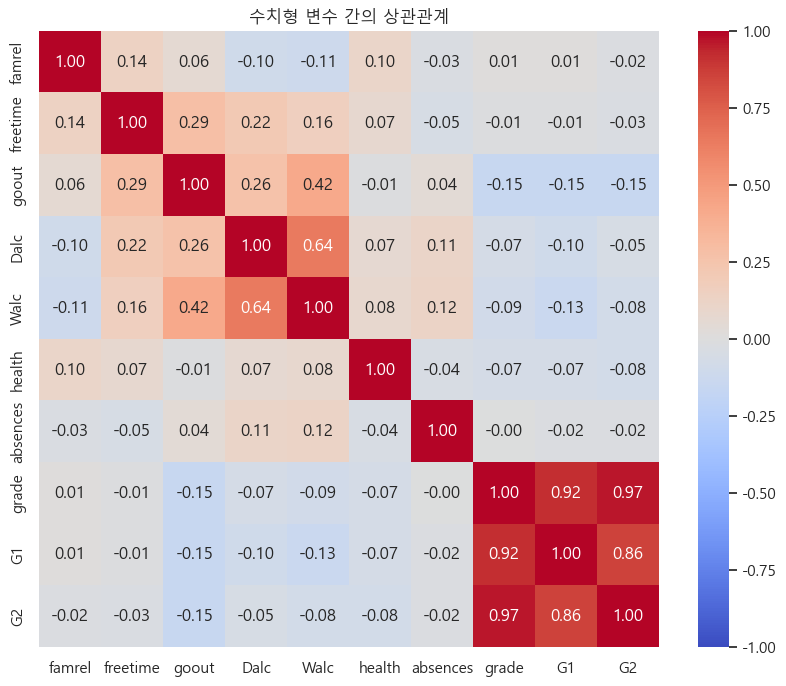

In [56]:
# 수치형 변수 간의 상관관계 분석(모름)
num_cols = df.select_dtypes(include=np.number).columns      # 모름
corr_matrix = df[num_cols].corr()   # 모름

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")  # 모름
plt.title('수치형 변수 간의 상관관계')
plt.show()

**수치형 변수 상관관계 분석 결과**

- `"grade"`, `"G1"`, `"G2"`간 강한 양의 상관관계가 나타나고 있다.
- `"Walc"`, `"Dalc"`간에도 양의 상관 관계가 보이고 있다.
- `"Walc"`, `"goout"`도 약한 양의 상관관계가 보이고 있다.

C:\Users\hambu\AppData\Local\Temp\ipykernel_46836\2322238325.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col] for col in num_cols], labels=num_cols)


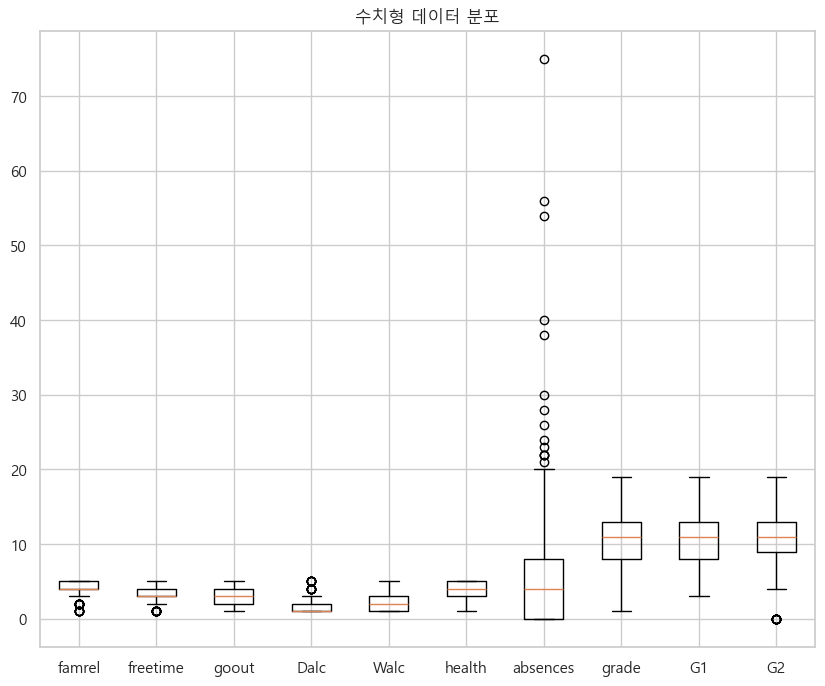

In [57]:
# float형 변수 int로 변환
for col in num_cols:
    df[col] = df[col].astype(int)

# 수치형 데이터 분포 시각화
plt.figure(figsize=(10, 8))
plt.boxplot([df[col] for col in num_cols], labels=num_cols)
plt.title('수치형 데이터 분포')
plt.show()

**수치형 데이터 분포 파악 결과**

- `"absences"`칼럼에 이상치 데이터 다량 분포(별도 확인 필요. `"famrel", "freetime", "Dalc", "G2"`도 결측치 존재)
- `"famrel", "freetime", "goout", "Dalc", "Walc", "health"`의 데이터 스케일이 비슷하고 나머지 4개 칼럼의 데이터 분포가 비슷하다.

### (2) 결측치를 식별·예측하는 두가지 방법을 쓰고 이를 선택한 이유를 설명하시오.
---
#### 1. `.info()`를 통한 확인 방법
`.info()`의 출력값에는 총 row의 길이가 나오며 각 column의 길이와 비교하여 파악할 수 있다. 가장 기초적으로 확인할 수 있는 방법이어서 사용했다.

#### 2. `.isnull().sum()`을 통한 확인 방법
`.isnull().sum()`는 직접적으로 column들의 결측치의 총계를 확인할 수 있기 때문에 결측치 제거 후 확인도 가능하며 가장 직관적인 방법이라 사용했다. 

### (3) 범주형 변수 인코딩이 필요한 경우를 식별하고, 변환을 적용하시오. 이를 선택한 이유를 설명하시오.
---
```
범주형 변수 인코딩이 필요한 경우는 데이터 클래스가 구분이 힘들거나 감성 분석 텍스트 마이닝 시 필요하다. 이번에 경우는 `"school"` column의 클래스가 구분이 힘들어 0,1로 구분을 하도록 하겠다.
``` 

In [75]:
# 범주형 변수 인코딩(모름)
school_map = {'GP': 0, 'MS': 1}
sex_map = {'F': 0, 'M': 1}
paid_map = {'yes': 0, 'no': 1}
activities_map = {'yes': 0, 'no': 1}

df['school_map'] = df['school'].map(school_map)
df['sex_map'] = df['sex'].map(sex_map)
df['paid_map'] = df['paid'].map(paid_map)
df['activities_map'] = df['activities'].map(activities_map)
df.head()

school_map        int64
sex_map           int64
paid_map          int64
activities_map    int64
dtype: object

### (4) 데이터 분할 방법을 2가지 쓰고 적절한 데이터 분할을 적용하시오. 이를 선택한 이유를 설명하시오.
---
```
기본적으로 학습, 평가 데이터를 랜덤하게 섞어 특정 비율(보통8:2)로 분할 하는 방법과 k개의 데이터로 분할하여 1개의 분할 데이터셋을 평가, 나머지를 학습데이터로 하여 k번 반복학습 결과중 최상의 결과를 채택하는 k-fold 교차 검증 방법이 있다.
```

가장 기본적인 랜덤 분할 방법을 선택할 것이고 빠른 결과 확인이 가능하기 때문에 사용하였다.

In [76]:
new_df = df.drop(columns=['school', 'sex', 'paid', 'activities'])

new_df.head()

,famrel,freetime,goout,Dalc,Walc,health,absences,grade,G1,G2,school_map,sex_map,paid_map,activities_map
0,4,3,4,1,1,3,6,6,5,6,0,0,1,1
1,5,3,3,1,1,3,4,5,5,5,0,0,1,1
2,4,3,2,2,3,3,10,8,7,8,0,0,0,1
3,3,2,2,1,1,5,2,15,15,14,0,0,0,0
4,4,3,2,1,2,5,4,9,6,10,0,0,0,1


In [77]:
X = new_df.drop(columns=['grade'])
y = new_df['grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
X

,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,school_map,sex_map,paid_map,activities_map
0,4,3,4,1,1,3,6,5,6,0,0,1,1
1,5,3,3,1,1,3,4,5,5,0,0,1,1
2,4,3,2,2,3,3,10,7,8,0,0,0,1
3,3,2,2,1,1,5,2,15,14,0,0,0,0
4,4,3,2,1,2,5,4,6,10,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,5,5,4,4,5,4,11,9,9,1,1,0,1
391,2,4,5,3,4,2,3,14,16,1,1,1,1
392,5,5,3,3,3,3,3,10,8,1,1,1,1
393,4,4,1,3,4,5,0,11,12,1,1,1,1


### (5) SVM, XGBoost, RandomForest 3개의 알고리즘 공통점을 쓰고 학생성적 예측 분석에 적합한 알고리즘인지 설명하시오.
---
#### a. 3모델의 공통점
- SVM, XGBoost, RandomForest 모두 회귀, 분류분석에서 사용할 수 있다.

#### b. 예측분석에 적합한 알고리즘인가?
- SVM: 마진(Margin)이 최대가 되는 회귀선을 구하는 방향으로 학습을 하게 된다. 단순한 선형관계를 갖는 데이터에선 효과적일 수 있겠지만 복잡한 관계를 갖는 데이터에선 성능이 좋지 못할 수 있다. 현재 데이터에선 다중공선성 문제가 있어보이는 칼럼이 일부 있어 성능이 낮다면 추가 전처리 필요가 있다.
- XGBoost GBM보다 발전한 모델(솔직히 잘 모르겠음). 하이퍼파라미터 설정이 복잡하긴 하지만 이상치에도 강하고 비선형 데이터에 좋은 예측성능을 보이기 때문에 적합하다 볼 수 있다.
- RandomForest: 이상치에 강한 예측모델이긴 하나 깊이가 깊어질 수록 해성하는데 어려움이 있다. XGBoost와 비교 모델로서 채택하기엔 적당할 수 있다.


### (6) 세 가지 모델 모두 모델링해보고 가장 적합한 알고리즘을 선택하시오. 이를 선택한 이유와 모델의 한계점, 보완 가능한 부분을 설명하고, 현업에서 주의할 점 등에 대해 기술하시오.

In [80]:
# SVM 모델 학습 및 평가(모름)
from sklearn.svm import SVC

# 모델 선언
svm_model = SVC(kernel='linear', random_state=42)

# 모델 학습
svm_model.fit(X_train, y_train)

# 모델 평가
svm_y_pred = svm_model.predict(X_test)

# 평가 지표 계산
svm_rmse = mean_squared_error(y_test, svm_y_pred)
print(f"SVM 모델 RMSE: {svm_rmse:.4f}")

SVM 모델 RMSE: 1.1447


In [81]:
# XGBoost 모델 학습 및 평가
from xgboost import XGBRegressor

# 모델 선언
xg_model = XGBRegressor(random_state=42)

# 모델 학습
xg_model.fit(X_train, y_train)

# 모델 평가
xg_y_pred = xg_model.predict(X_test)

xg_rmse = mean_squared_error(y_test, xg_y_pred)
print(f"XGBoost 모델 RMSE: {xg_rmse:.4f}")

XGBoost 모델 RMSE: 0.6884


In [82]:
# Random Forest 모델 학습 및 평가
from sklearn.ensemble import RandomForestRegressor

# 모델 선언
rf_model = RandomForestRegressor(random_state=42)

# 모델 학습
rf_model.fit(X_train, y_train)

# 모델 평가
rf_y_pred = rf_model.predict(X_test)
rf_rmse = mean_squared_error(y_test, rf_y_pred)
print(f"Random Forest 모델 RMSE: {rf_rmse:.4f}")

Random Forest 모델 RMSE: 0.6519
